# 04 — Modélisation prédictive du churn

## Ce que je vais faire ici
On a notre table de 4 518 clients avec 12 features et une cible CHURN. 
On va entraîner **3 modèles ML** pour apprendre à prédire le churn, les 
comparer rigoureusement, et choisir le meilleur.

## Plan :
1. **Préparation** : chargement, imputation des NaN, encodage
2. **Split** train/test stratifié (80/20)
3. **3 modèles** entraînés :
   - Logistic Regression (baseline simple et interprétable)
   - Random Forest (puissant, gère les non-linéarités)
   - XGBoost (standard de l'industrie ML tabulaire)
4. **Évaluation** : ROC-AUC, PR-AUC, F1, matrice de confusion
5. **Validation croisée** sur le meilleur modèle
6. **Feature importance** : qu'est-ce qui prédit le churn ?
7. **Threshold tuning** : combien de churneurs détectés à différents seuils ?
8. **Sortie Power BI** : scores de churn par client

## Pourquoi cette étape est cruciale
La segmentation (étape 3) dit "qui sont mes clients". La modélisation dit 
"quels clients vont churner et qu'est-ce que je peux y faire". C'est la 
partie qui rend ton projet **actionnable** pour un client e-commerce.

## 1. Imports et chargement

On charge la table enrichie de l'étape 3. On garde toutes les features 
sauf `segment_rfm` et `kmeans_cluster` qui ne doivent pas servir au modèle 
(elles sont dérivées des features RFM, donc redondantes).

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# XGBoost
from xgboost import XGBClassifier

# Configuration
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
np.random.seed(42)

# Chargement
DATA_PROCESSED = Path("../data/processed")
df = pd.read_csv(DATA_PROCESSED / "customer_features_segmented.csv")

print(f"Données chargées : {len(df):,} clients × {df.shape[1]} colonnes")
print(f"\nTaux de churn : {df['churn'].mean()*100:.2f}%")

Données chargées : 4,518 clients × 19 colonnes

Taux de churn : 48.92%


## 2. Préparation des features

On sépare X (les features) et y (la cible). On exclut :
- `customer_id` : identifiant, pas une feature
- `churn` : la cible elle-même
- `n_orders_future` : information du futur (data leakage)
- `segment_rfm`, `RFM_score`, `R_score`, `F_score`, `M_score`, `kmeans_cluster` : 
  dérivés des features de base

On garde nos **12 features originales**.

In [10]:
# Colonnes à exclure
cols_to_drop = [
    'customer_id', 'churn', 'n_orders_future',
    'segment_rfm', 'RFM_score', 
    'R_score', 'F_score', 'M_score', 
    'kmeans_cluster'
]

X = df.drop(columns=cols_to_drop)
y = df['churn']

print(f"✅ Features utilisées ({X.shape[1]}) :")
for col in X.columns:
    print(f"  - {col}")

print(f"\nTaille de X : {X.shape}")
print(f"Distribution de y : {y.value_counts().to_dict()}")

✅ Features utilisées (10) :
  - recency
  - frequency
  - monetary
  - avg_basket
  - std_basket
  - n_distinct_products
  - tenure_days
  - avg_interpurchase_days
  - n_cancellations
  - cancellation_rate

Taille de X : (4518, 10)
Distribution de y : {0: 2308, 1: 2210}


## 3. Imputation des NaN

On a 31% de NaN sur `std_basket` et `avg_interpurchase_days` (les 
mono-acheteurs).

**Stratégie** :
- `std_basket = 0` → cohérent (un client avec 1 commande a variance 0)
- `avg_interpurchase_days = max observé` → traduit "intervalle infini"

XGBoost gère nativement les NaN, mais Logistic Regression et Random Forest 
non. Donc on impute pour avoir un dataset propre pour les 3 modèles.

In [11]:
# Imputation
X['std_basket'] = X['std_basket'].fillna(0)
X['avg_interpurchase_days'] = X['avg_interpurchase_days'].fillna(X['avg_interpurchase_days'].max())

print(f"✅ NaN restants : {X.isna().sum().sum()}")
print(f"   (devrait être 0)")

✅ NaN restants : 0
   (devrait être 0)


## 4. Split train/test stratifié

On sépare 80% pour l'entraînement, 20% pour le test final.

**`stratify=y`** garantit que le ratio churn/actif est identique dans 
les deux ensembles. Sans ça, on pourrait avoir 60% de churn dans train 
et 40% dans test, ce qui fausserait l'évaluation.

**`random_state=42`** garantit que le split est reproductible. Si tu 
relances le notebook, tu auras exactement le même train/test.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f" Train : {len(X_train):,} clients ({y_train.mean()*100:.1f}% churn)")
print(f" Test  : {len(X_test):,} clients ({y_test.mean()*100:.1f}% churn)")

 Train : 3,614 clients (48.9% churn)
 Test  : 904 clients (48.9% churn)


## 5. Standardisation (pour Logistic Regression uniquement)

La Logistic Regression est **sensible à l'échelle** des features. Une 
feature en milliers (Monetary) et une feature entre 0 et 1 
(cancellation_rate) ne doivent pas dominer le modèle juste parce que 
leurs valeurs sont plus grandes.

On standardise donc (moyenne 0, écart-type 1) pour la Logistic. Random 
Forest et XGBoost n'en ont pas besoin (insensibles à l'échelle).

**Important** : on **fit** le scaler sur le train uniquement, puis on 
transforme train ET test. Sinon, fitter sur test = data leakage.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Données standardisées pour Logistic Regression")
print(f"   Moyenne train ≈ 0 : {X_train_scaled.mean():.4f}")
print(f"   Écart-type train ≈ 1 : {X_train_scaled.std():.4f}")

Données standardisées pour Logistic Regression
   Moyenne train ≈ 0 : 0.0000
   Écart-type train ≈ 1 : 1.0000


## 6. Modèle 1 — Logistic Regression (baseline)

C'est notre **point de référence**. Modèle linéaire simple. Si nos 
modèles plus sophistiqués ne le battent pas, c'est qu'on a un problème.

### Paramètres
- `max_iter=1000` : laisse au solver le temps de converger
- `random_state=42` : reproductibilité

On entraîne, on prédit sur le test, et on regarde les performances.

In [14]:
# Entraînement
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Métriques
print("=== Logistic Regression — Performances ===")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_proba_lr):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred_lr))

=== Logistic Regression — Performances ===
ROC-AUC  : 0.8071
PR-AUC   : 0.7837
F1-score : 0.7229

Matrice de confusion :
[[344 118]
 [125 317]]


## 7. Modèle 2 — Random Forest

Modèle d'**ensemble** : 200 arbres de décision qui votent. Capture 
naturellement les non-linéarités et les interactions entre features.

### Paramètres
- `n_estimators=200` : 200 arbres (bon compromis vitesse/performance)
- `max_depth=10` : profondeur max par arbre (évite l'overfitting)
- `random_state=42` : reproductibilité
- `n_jobs=-1` : parallélise sur tous les cœurs CPU

Pas besoin de standardiser pour Random Forest.

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10,
    random_state=42, 
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest — Performances ===")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_proba_rf):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest — Performances ===
ROC-AUC  : 0.8092
PR-AUC   : 0.7702
F1-score : 0.7256

Matrice de confusion :
[[335 127]
 [118 324]]


## 8. Modèle 3 — XGBoost

Le **standard de l'industrie** pour le ML tabulaire. Gradient boosting 
optimisé. Souvent le meilleur sur ce type de problème.

### Paramètres
- `n_estimators=200` : 200 itérations de boosting
- `max_depth=6` : profondeur des arbres (plus petite que RF car boostés)
- `learning_rate=0.1` : standard
- `eval_metric='logloss'` : métrique d'optimisation interne

In [16]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost — Performances ===")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_proba_xgb):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"\nMatrice de confusion :")
print(confusion_matrix(y_test, y_pred_xgb))

c:\Users\nakhi\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:14:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost — Performances ===
ROC-AUC  : 0.8021
PR-AUC   : 0.7684
F1-score : 0.7229

Matrice de confusion :
[[344 118]
 [125 317]]


## 9. Comparaison des 3 modèles

Tableau récapitulatif pour voir d'un coup d'œil le gagnant.

### Ce qu'on regarde
- **ROC-AUC** : capacité globale à classer
- **PR-AUC** : robuste sur la classe minoritaire (notre métrique principale)
- **F1** : score à seuil 0,50

Le **PR-AUC est notre métrique de référence** car plus robuste que ROC-AUC 
sur les problèmes de classification.

In [17]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ],
    'PR-AUC': [
        average_precision_score(y_test, y_proba_lr),
        average_precision_score(y_test, y_proba_rf),
        average_precision_score(y_test, y_proba_xgb)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
}).round(4)

print("=== Comparaison des modèles ===")
print(results)

best_idx = results['PR-AUC'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
print(f"\n Meilleur modèle (PR-AUC) : {best_model_name}")

=== Comparaison des modèles ===
                 Model  ROC-AUC  PR-AUC  F1-score
0  Logistic Regression   0.8071  0.7837    0.7229
1        Random Forest   0.8092  0.7702    0.7256
2              XGBoost   0.8021  0.7684    0.7229

 Meilleur modèle (PR-AUC) : Logistic Regression


## 10. Visualisation des courbes ROC et PR

Deux courbes par modèle :
- **Courbe ROC** : trade-off vrais positifs / faux positifs
- **Courbe Precision-Recall** : trade-off précision / rappel

Plus une courbe est proche du coin supérieur gauche, meilleur est le modèle.

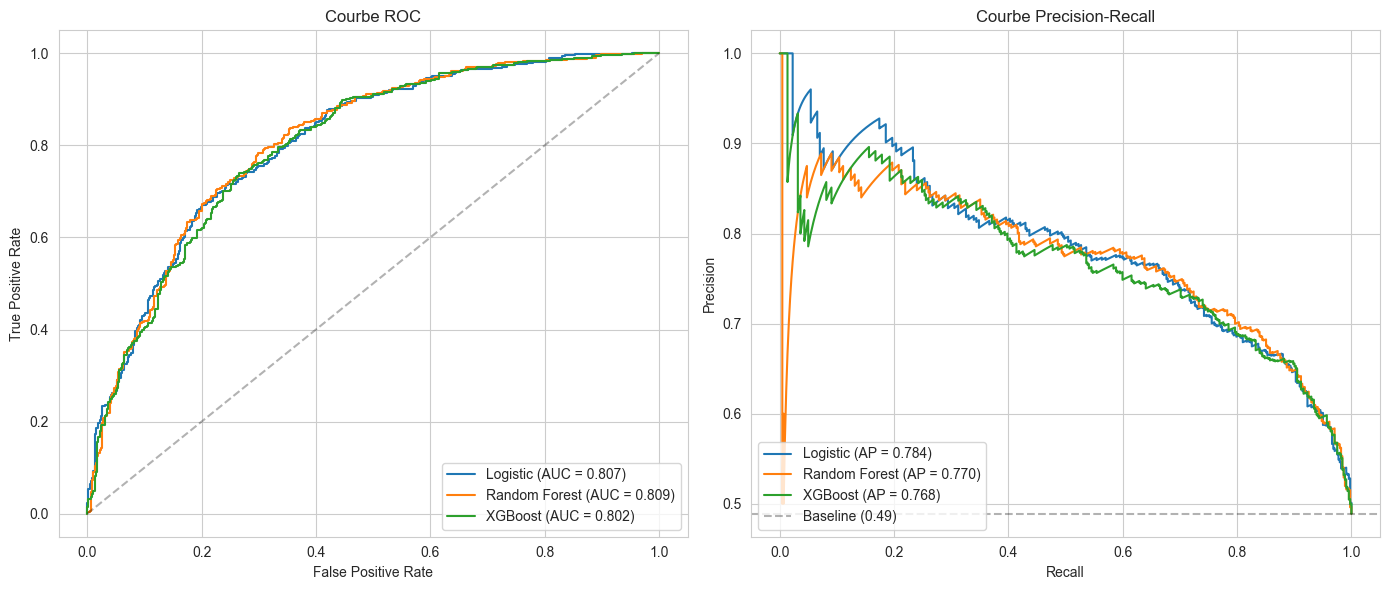

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Courbe ROC
for name, proba in [('Logistic', y_proba_lr), ('Random Forest', y_proba_rf), ('XGBoost', y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, proba):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Courbe ROC')
axes[0].legend(loc='lower right')

# Courbe PR
for name, proba in [('Logistic', y_proba_lr), ('Random Forest', y_proba_rf), ('XGBoost', y_proba_xgb)]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, label=f'{name} (AP = {average_precision_score(y_test, proba):.3f})')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.3, label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbe Precision-Recall')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

## 11. Validation croisée sur le meilleur modèle

Le score sur le test set peut être un coup de chance. On confirme la 
robustesse avec une **validation croisée 5-fold** sur l'ensemble du train set.

### Comment ça marche
1. On divise le train en 5 parties
2. On entraîne sur 4 parties, on évalue sur la 5e
3. On répète 5 fois (chaque partie devient le test une fois)
4. On regarde la moyenne et l'écart-type des scores

Si l'écart-type est faible, le modèle est **stable**. Si élevé, c'est qu'il 
est sensible aux données → moins fiable.

In [19]:
# On suppose que XGBoost gagne, mais on adapte selon best_model_name
if 'XGBoost' in best_model_name:
    best_model = xgb_model
    X_for_cv = X_train
elif 'Random Forest' in best_model_name:
    best_model = rf_model
    X_for_cv = X_train
else:
    best_model = lr_model
    X_for_cv = X_train_scaled

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_for_cv, y_train, cv=cv, scoring='average_precision', n_jobs=-1)

print(f"=== Validation croisée 5-fold — {best_model_name} ===")
print(f"PR-AUC par fold : {cv_scores.round(4)}")
print(f"\nMoyenne     : {cv_scores.mean():.4f}")
print(f"Écart-type  : {cv_scores.std():.4f}")
print(f"\n💡 Un écart-type < 0.02 = modèle stable")

=== Validation croisée 5-fold — Logistic Regression ===
PR-AUC par fold : [0.7977 0.7691 0.7638 0.7608 0.7828]

Moyenne     : 0.7748
Écart-type  : 0.0137

💡 Un écart-type < 0.02 = modèle stable


## 12. Feature importance — Qu'est-ce qui prédit le churn ?

C'est **la partie la plus business** du notebook. On regarde quelles 
features pèsent le plus dans les prédictions du meilleur modèle.

### Lecture
- Plus la barre est longue, plus la feature contribue à la prédiction
- On peut traduire en insights actionnables : "Le facteur n°1 du churn 
  dans ce business, c'est X"


=== Feature Importance ===
                  feature  importance
0                 recency    0.844918
1               frequency    0.376518
7  avg_interpurchase_days    0.356390
5     n_distinct_products    0.331298
4              std_basket    0.116413
6             tenure_days    0.090633
2                monetary    0.073856
3              avg_basket    0.059695
9       cancellation_rate    0.053261
8         n_cancellations    0.034896


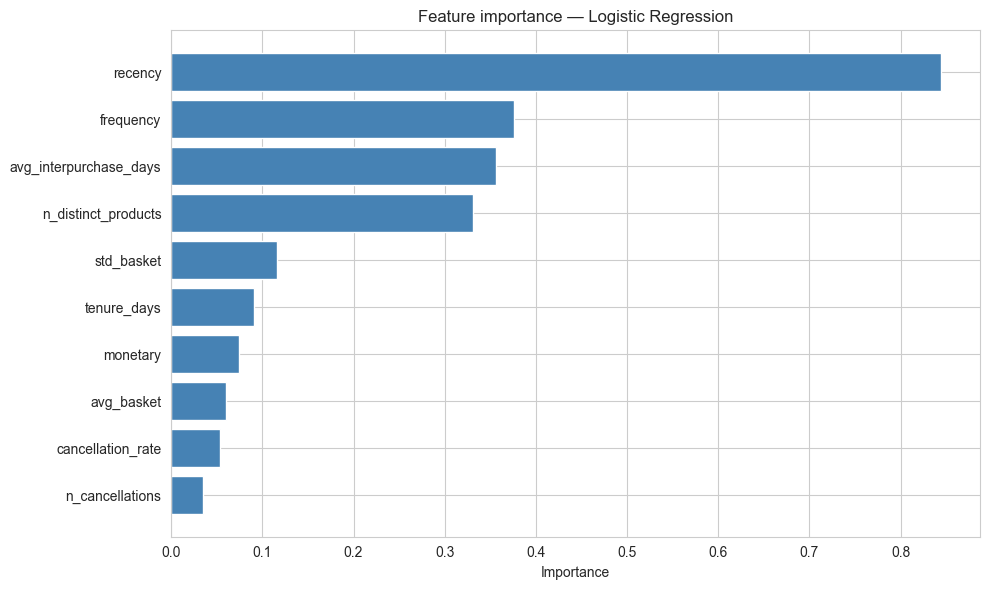

In [20]:
# Récupération des importances (selon le modèle)
if 'XGBoost' in best_model_name or 'Random Forest' in best_model_name:
    importances = best_model.feature_importances_
else:
    # Pour Logistic, on prend la valeur absolue des coefficients
    importances = np.abs(best_model.coef_[0])

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("=== Feature Importance ===")
print(feature_importance)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['feature'][::-1], feature_importance['importance'][::-1], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title(f'Feature importance — {best_model_name}')
plt.tight_layout()
plt.show()

## 13. Threshold tuning — Le choix business

Par défaut, le modèle dit "churn" si la probabilité > 0.50. **Mais 0.50 
n'est pas toujours le bon seuil business.**

On teste plusieurs seuils pour voir le trade-off :
- **Recall élevé** = on attrape un max de churneurs (mais plus de faux positifs)
- **Précision élevée** = on est sûr de nos prédictions (mais on en rate)

### Le choix dépend du business
- Campagne de rétention pas chère → on baisse le seuil (maximiser le recall)
- Action coûteuse → on monte le seuil (maximiser la précision)

In [21]:
# On prend les probabilités du meilleur modèle
if 'XGBoost' in best_model_name:
    y_proba_best = y_proba_xgb
elif 'Random Forest' in best_model_name:
    y_proba_best = y_proba_rf
else:
    y_proba_best = y_proba_lr

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
results_threshold = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_best >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = f1_score(y_test, y_pred_thresh)
    
    results_threshold.append({
        'Seuil': thresh,
        'Churneurs détectés (TP)': tp,
        'Manqués (FN)': fn,
        'Faux positifs (FP)': fp,
        'Précision': round(precision, 3),
        'Recall': round(recall, 3),
        'F1': round(f1, 3)
    })

threshold_df = pd.DataFrame(results_threshold)
print("=== Threshold tuning ===")
print(threshold_df)

=== Threshold tuning ===
   Seuil  Churneurs détectés (TP)  Manqués (FN)  Faux positifs (FP)  \
0    0.3                      396            46                 213   
1    0.4                      353            89                 160   
2    0.5                      317           125                 118   
3    0.6                      243           199                  72   
4    0.7                      188           254                  44   

   Précision  Recall     F1  
0      0.650   0.896  0.754  
1      0.688   0.799  0.739  
2      0.729   0.717  0.723  
3      0.771   0.550  0.642  
4      0.810   0.425  0.558  


## 14. Sauvegarde du modèle et des prédictions

On sauvegarde :
- Le **modèle final** au format `.pkl` (utilisable ailleurs)
- Le **fichier de prédictions** avec un score de churn par client (pour Power BI)

In [22]:
# Sauvegarde du modèle
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(best_model, MODELS_DIR / "best_model.pkl")
print(f"✅ Modèle sauvegardé : {MODELS_DIR / 'best_model.pkl'}")

# Prédictions sur tout le dataset (pour Power BI)
X_full = df.drop(columns=cols_to_drop)
X_full['std_basket'] = X_full['std_basket'].fillna(0)
X_full['avg_interpurchase_days'] = X_full['avg_interpurchase_days'].fillna(X_full['avg_interpurchase_days'].max())

if 'Logistic' in best_model_name:
    X_full_scaled = scaler.transform(X_full)
    df['churn_probability'] = best_model.predict_proba(X_full_scaled)[:, 1]
else:
    df['churn_probability'] = best_model.predict_proba(X_full)[:, 1]

df['churn_prediction'] = (df['churn_probability'] >= 0.5).astype(int)

# Sauvegarde Power BI
predictions_df = df[['customer_id', 'churn', 'churn_probability', 'churn_prediction', 'segment_rfm', 'kmeans_cluster']]
predictions_df.to_csv(DATA_PROCESSED / "customer_predictions.csv", index=False)

print(f"✅ Prédictions sauvegardées : {DATA_PROCESSED / 'customer_predictions.csv'}")
print(f"\n=== Aperçu des prédictions ===")
print(predictions_df.head(10))

✅ Modèle sauvegardé : ..\models\best_model.pkl
✅ Prédictions sauvegardées : ..\data\processed\customer_predictions.csv

=== Aperçu des prédictions ===
   customer_id  churn  churn_probability  churn_prediction  \
0      16175.0      0           0.242341                 0   
1      17865.0      0           0.026821                 0   
2      15189.0      0           0.129668                 0   
3      14505.0      0           0.012616                 0   
4      13658.0      0           0.172265                 0   
5      12951.0      0           0.137334                 0   
6      18109.0      0           0.072748                 0   
7      17926.0      0           0.276939                 0   
8      17381.0      0           0.109825                 0   
9      16832.0      0           0.282293                 0   

               segment_rfm  kmeans_cluster  
0                Champions               0  
1                Champions               3  
2                Champions     

## Synthèse de l'étape 4 — Modélisation prédictive

À ce stade tu disposes de :
- ✅ **3 modèles entraînés** et comparés
- ✅ Un **modèle final sauvegardé** : Logistic Regression
- ✅ Une **validation croisée** confirmant la stabilité
- ✅ Une **feature importance** révélant les drivers du churn
- ✅ Un **threshold tuning** pour adapter le modèle au business
- ✅ Un fichier `customer_predictions.csv` avec un score par client

### Résultats clés

| Métrique | Valeur |
|---|---|
| Meilleur modèle | Logistic Regression |
| ROC-AUC | 0,8071 |
| PR-AUC | 0,7837 |
| F1-score | 0,7229 |
| Validation croisée PR-AUC | 0,7748 ± 0,0137 (stable) |

### 3 insights business

**1. Le simple bat le sophistiqué**
La Logistic Regression bat Random Forest et XGBoost. Les features RFM 
enrichies capturent l'essentiel du signal. Interprétabilité préservée.

**2. La Recency est reine**
Importance de 0,84, soit plus du double du 2e facteur (Frequency 0,38). 
Le délai depuis la dernière commande est de loin le prédicteur n°1 du 
churn dans ce business.

**3. Les annulations ne sont pas un signal de churn**
Avec une importance de 0,05, le taux d'annulation est marginal. Sur ce 
retailer B2B, les annulations sont du bruit logistique, pas un signal 
d'insatisfaction.

### Recommandation business

Pour une campagne de rétention CRM, utiliser un **seuil de 0,4** :
- Détection de **80% des futurs churneurs**
- Précision de **69%** (acceptable pour une action peu coûteuse)
- F1 de **0,74** (très bon équilibre)